# sabre demo

Narrates Jupyter cell outputs using Claude. Run top-to-bottom.

**Before you start:** `export ANTHROPIC_API_KEY=sk-ant-...` before launching Jupyter (or set it in a cell with `%env` — see below).

In [ ]:
# Optional — set the key here if it isn't in your shell environment.
# %env ANTHROPIC_API_KEY=sk-ant-...

In [ ]:
%load_ext sabre
from sabre import explain

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. DataFrame

A fake sales dataset with a deliberate outlier and some nulls.

In [2]:
n = 500
df = pd.DataFrame({
    "region": rng.choice(["north", "south", "east", "west"], size=n),
    "units": rng.poisson(lam=12, size=n),
    "price": rng.normal(loc=49.99, scale=5, size=n).round(2),
    "discount_pct": rng.beta(2, 8, size=n).round(3),
    "returned": rng.random(n) < 0.07,
})
# Planted oddities: one huge outlier + some missing prices
df.loc[0, "units"] = 9999
df.loc[df.sample(25, random_state=1).index, "price"] = np.nan
df

,region,units,price,discount_pct,returned
0,north,9999,42.72,0.187,False
1,west,9,43.68,0.016,False
2,east,16,50.14,0.050,False
3,south,8,55.13,0.204,False
4,south,10,38.92,0.194,False
...,...,...,...,...,...
495,south,9,49.01,0.105,False
496,north,21,48.28,0.099,False
497,south,11,42.96,0.162,False
498,west,9,40.10,0.179,False


In [3]:
explain()   # narrates the DataFrame above

**`units` has a sentinel/outlier problem.** Max is 9999 vs. a 75th percentile of 15 and median 12 — almost certainly a placeholder (or data entry error) inflating the mean to 32 and std to 447. Row 0 already shows one. Filter or treat as NA before any aggregation.

Other notes:
- **`price` has 25 nulls (5%)** — decide on imputation vs. drop; distribution otherwise tight (~$35–65).
- **`discount_pct`** looks clean (0–67%), though 67% is worth spot-checking.
- **`region`** is well-balanced across 4 values; south slightly over-represented (134/500).
- **`returned`** is bool — describe() didn't summarize it; check the return rate separately, it may be heavily imbalanced (all False in the head).
- Consider casting `region` to `category` for memory/groupby efficiency.

## 2. Matplotlib figure

Claude gets the PNG via vision and describes what the chart actually shows.

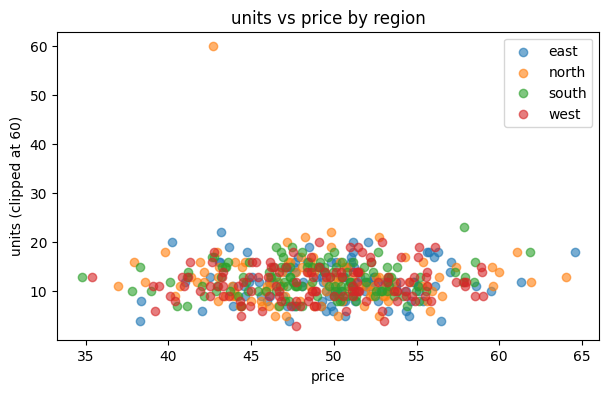

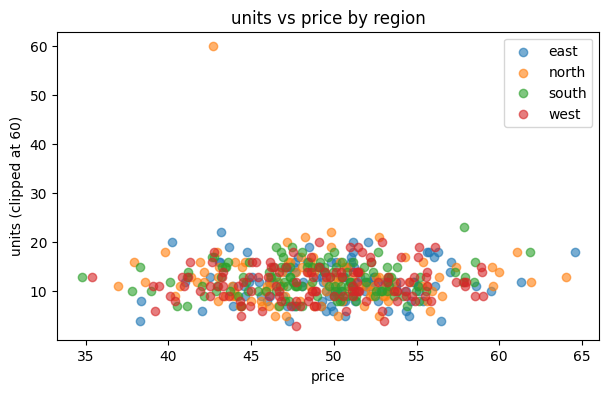

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for region, g in df.groupby("region"):
    ax.scatter(g["price"], g["units"].clip(upper=60), label=region, alpha=0.6)
ax.set_xlabel("price")
ax.set_ylabel("units (clipped at 60)")
ax.set_title("units vs price by region")
ax.legend()
fig

In [5]:
explain(fig)

Scatter of units vs price, colored by region (east/north/south/west). No visible trend — units sit in a flat band roughly 3–23 across prices ~35–65, so price and units look essentially uncorrelated in this range.

Notable:
- One clear outlier: a north point at price ≈43, units = 60. Since the y-axis label says "clipped at 60," this is almost certainly a censored value — the true units could be higher. Worth checking how many rows were clipped before trusting any summary stats.
- Regions are heavily overlapping with no obvious separation in either axis; no region-specific slope stands out.
- Point density is highest between price 45–55, units 10–15 — typical bulk of the data.
- A few low-unit points (≤5) scattered across the price range, but nothing extreme on the low side.

## 3. Series

In [6]:
df["region"].value_counts()

region
south    134
west     125
north    122
east     119
Name: count, dtype: int64

In [7]:
explain()

Counts by region are tightly clustered (119–134, mean 125). **South** is the high outlier at 134 (~+1.4σ); **east** lowest at 119. Spread is small (std ~6.5, ~5% of mean) — regions are roughly balanced, no dominant region.

## 4. Traceback

Catch an exception and pass it to `explain` — it points at the failing line and suggests a fix.

In [ ]:
try:
    total = df["region"].sum() + df["units"].mean()   # can't sum strings + float
except Exception as e:
    err = e

explain(err)

## 5. Numpy array

In [ ]:
arr = rng.normal(size=(1000, 3))
arr[::100] *= 20   # plant some outliers
arr

In [ ]:
explain()

## 6. `%explain` line magic

Same as `explain()`. With an argument, evaluates the expression first.

In [ ]:
df.describe()

In [ ]:
%explain

In [ ]:
%explain df[df['units'] > 100]